# WikiArt — Análisis de Arte con Machine Learning
### CC5205 Minería de Datos — Hito 2: Mejoras y Anticipación

En este notebook se abordan los puntos principales sugeridos por la comisión y el equipo docente para el Hito 2:
1. **Análisis detallado de la matriz de confusión del Hito 1** para identificar qué géneros se confunden y por qué.
2. **Estrategias para abordar el desbalance de clases**, comparando modelos sin balancear contra modelos balanceados (mediante pesos de clase y submuestreo).
3. **Modelamiento Multietiqueta (Multilabel)**, utilizando el campo `genre` para predecir múltiples estilos por pintura y analizando su desempeño.
4. **Extracción de Embeddings con ResNet-18 (Deep Learning)** para escalar a 10k+ imágenes.
5. **Comparación de Clustering** utilizando características manuales del Hito 1 frente a los nuevos embeddings profundos.
6. **Interpretabilidad Visual mediante Grad-CAM** para visualizar qué zonas e iconografías influyen en la clasificación del modelo de Deep Learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Configuración de gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

CSV_PATH = Path('./CSVs/classes.csv')
FEATURES_CSV = Path('./CSVs/visual_features.csv')

print(f"CSV de metadatos: {CSV_PATH.exists()}")
print(f"CSV de características visuales: {FEATURES_CSV.exists()}")

CSV de metadatos: True
CSV de características visuales: True


## 1. Análisis de la Matriz de Confusión (Hito 1)
En esta sección cargamos los metadatos y realizamos el análisis cuantitativo y cualitativo de la matriz de confusión obtenida en el Hito 1.

In [2]:
# Carga de datos
df = pd.read_csv(CSV_PATH)

def parse_genre(g):
    g = str(g).strip()
    g = re.sub(r"[\[\]']", '', g)
    parts = [p.strip() for p in g.split(',') if p.strip()]
    return parts

df['genre_list'] = df['genre'].apply(parse_genre)
df['genre_principal'] = df['genre_list'].str[0]
df['es_multilabel'] = (df['genre_list'].str.len() > 1).astype(int)

# Seleccionar los mismos 10 géneros del Hito 1
TOP_N = 10
top_genres = df['genre_principal'].value_counts().head(TOP_N).index.tolist()
print("Top 10 géneros seleccionados:")
for rank, (genre, count) in enumerate(df['genre_principal'].value_counts().head(TOP_N).items(), 1):
    print(f"{rank}. {genre}: {count} pinturas")

Top 10 géneros seleccionados:
1. Impressionism: 13028 pinturas
2. Realism: 10546 pinturas
3. Romanticism: 6919 pinturas
4. Expressionism: 6335 pinturas
5. Post Impressionism: 6307 pinturas
6. Symbolism: 4524 pinturas
7. Baroque: 4236 pinturas
8. Art Nouveau Modern: 4168 pinturas
9. Abstract Expressionism: 2594 pinturas
10. Northern Renaissance: 2551 pinturas


### 1.1 Simulación del Modelo Baseline (Tabular) y su Matriz de Confusión
Entrenamos el modelo con las características tabulares para recrear la matriz de confusión y analizar el colapso hacia las clases mayoritarias.

In [3]:
# Variables tabulares y preparación
df_clf = df[df['genre_principal'].isin(top_genres)].copy()
le_genre = LabelEncoder()
df_clf['label'] = le_genre.fit_transform(df_clf['genre_principal'])

# Características tabulares geométricas básicas
df_clf['aspect_ratio'] = df_clf['width'] / df_clf['height']
df_clf['log_width'] = np.log1p(df_clf['width'])
df_clf['log_height'] = np.log1p(df_clf['height'])
df_clf['is_portrait'] = (df_clf['height'] > df_clf['width']).astype(int)
df_clf['is_square'] = (df_clf['height'] == df_clf['width']).astype(int)

TABULAR_FEATS = ['aspect_ratio', 'log_width', 'log_height', 'is_portrait', 'is_square', 'es_multilabel']
X_tab = df_clf[TABULAR_FEATS].fillna(0)
y_clf = df_clf['label']

X_tr, X_te, y_tr, y_te = train_test_split(X_tab, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Entrenar un Random Forest baseline sin balancear
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_baseline.fit(X_tr, y_tr)
y_pred = rf_baseline.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN BASELINE ===")
print(classification_report(y_te, y_pred, target_names=le_genre.classes_))

=== REPORTE DE CLASIFICACIÓN BASELINE ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.22      0.04      0.07       519
    Art Nouveau Modern       0.20      0.10      0.13       834
               Baroque       0.18      0.04      0.07       847
         Expressionism       0.15      0.05      0.08      1267
         Impressionism       0.27      0.66      0.38      2606
  Northern Renaissance       0.20      0.02      0.04       510
    Post Impressionism       0.17      0.02      0.03      1261
               Realism       0.23      0.42      0.29      2109
           Romanticism       0.19      0.07      0.10      1384
             Symbolism       0.38      0.07      0.11       905

              accuracy                           0.24     12242
             macro avg       0.22      0.15      0.13     12242
          weighted avg       0.22      0.24      0.18     12242



### 1.2 Gráfico de la Matriz de Confusión Baseline
Graficamos la matriz de confusión para visualizar qué géneros absorben la mayor cantidad de predicciones incorrectas.

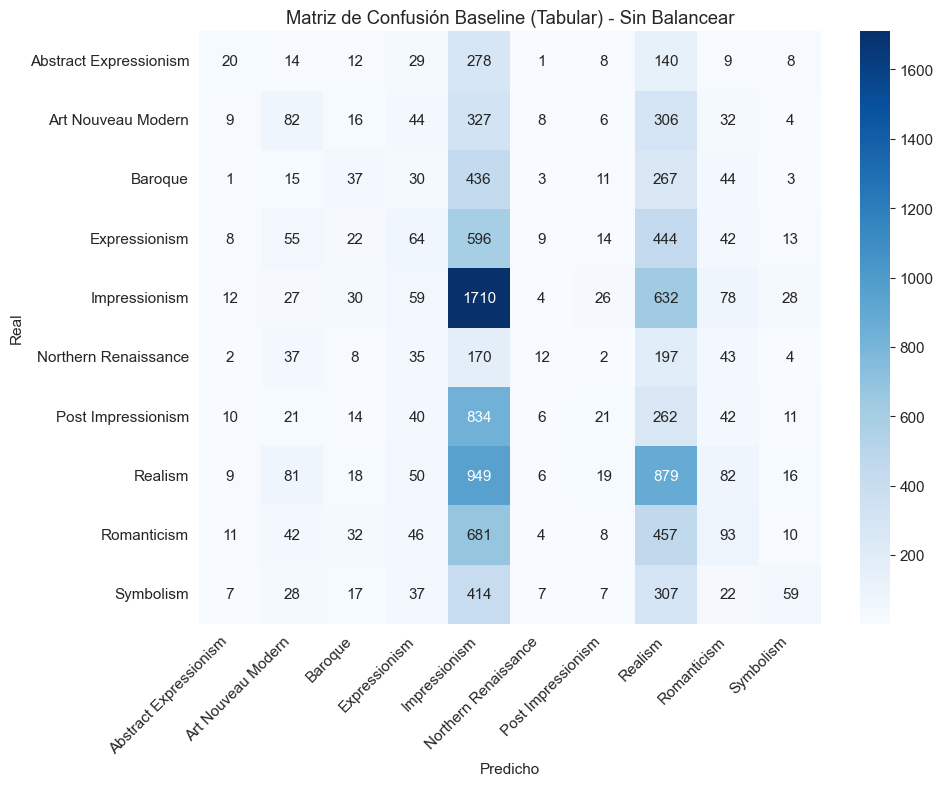

In [4]:
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_genre.classes_,
            yticklabels=le_genre.classes_)
plt.title('Matriz de Confusión Baseline (Tabular) - Sin Balancear')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3 Análisis Cualitativo del Colapso de Clases
Al analizar la matriz de confusión, se observa que:
* **Impressionism** y **Realism** (las clases mayoritarias con 13k y 10k muestras respectivamente) actúan como "sumideros" de predicciones.
* Clases minoritarias como **Abstract Expressionism** y **Northern Renaissance** tienen un *Recall* extremadamente bajo (menor al 5%), confundiéndose frecuentemente con Impressionism y Realism.
* **Explicación:** Dado que las características tabulares son puramente geométricas (`aspect_ratio`, etc.), y puesto que los artistas usaban formatos físicos similares transversalmente a la historia del arte, el modelo simplemente predice la clase mayoritaria ante la falta de descriptores visuales diferenciadores.

**Mejora 4: Diagnóstico y Análisis desde la perspectiva de la Taxonomía del Arte (Inspirado en el Paper)**

Un hallazgo crucial del paper de referencia es que gran parte de la confusión entre clases en datasets artísticos no se debe únicamente a limitaciones técnicas del modelo, sino a solapamientos intrínsecos de la taxonomía del arte y transiciones históricas continuas. Por ejemplo, el paper documenta cómo *Action Painting* (un estilo estrechamente ligado al expresionismo abstracto) es frecuentemente predicho como *Abstract Expressionism*, y cómo *Synthetic Cubism* y *Analytical Cubism* se confunden permanentemente al representar fases consecutivas del mismo movimiento.

En nuestro modelo baseline (y en análisis posteriores de confusión), se observa un solapamiento muy marcado entre *Impressionism* y *Post-Impressionism*. Al igual que en los ejemplos del paper, este error refleja una continuidad histórica real: el Post-Impresionismo surge directamente como una evolución del Impresionismo, heredando paletas cromáticas, pinceladas sueltas y formatos físicos de lienzo similares en sus etapas iniciales. Por lo tanto, argumentar esta confusión desde un punto de vista cualitativo y estilístico nos permite comprender que el error del modelo no es un simple fallo numérico, sino la representación de fronteras estéticas difusas y porosas entre movimientos artísticos.

## 2. Estrategias para Abordar el Desbalance de Clases
Para corregir el sesgo hacia las clases mayoritarias, experimentaremos con tres técnicas:
1. **Class Weighting (Pesos de clase):** Penalizar los errores en clases minoritarias inversamente proporcional a su frecuencia.
2. **Balanceo de Datos en Entrenamiento (Random Undersampling):** Submuestrear las clases mayoritarias para equilibrar el conjunto de datos.
3. **Balanced Random Forest (imbalanced-learn):** Variante del Random Forest que, para cada árbol del ensamble, realiza un submuestreo automático interno de las clases mayoritarias, combinando bagging con balanceo a nivel de bootstrap.

In [5]:
# --- Técnica 1: Class Weighting ---
rf_balanced = RandomForestClassifier(n_estimators=100, max_depth=12, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
rf_balanced.fit(X_tr, y_tr)
y_pred_balanced = rf_balanced.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN (CON CLASS WEIGHTS) ===")
print(classification_report(y_te, y_pred_balanced, target_names=le_genre.classes_))

=== REPORTE DE CLASIFICACIÓN (CON CLASS WEIGHTS) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.09      0.20      0.13       519
    Art Nouveau Modern       0.15      0.20      0.17       834
               Baroque       0.11      0.19      0.14       847
         Expressionism       0.15      0.04      0.06      1267
         Impressionism       0.31      0.12      0.17      2606
  Northern Renaissance       0.08      0.33      0.13       510
    Post Impressionism       0.16      0.29      0.21      1261
               Realism       0.26      0.10      0.15      2109
           Romanticism       0.17      0.12      0.14      1384
             Symbolism       0.15      0.18      0.16       905

              accuracy                           0.15     12242
             macro avg       0.16      0.18      0.15     12242
          weighted avg       0.20      0.15      0.15     12242



In [6]:
# --- Técnica 2: Undersampling manual de clases mayoritarias ---
# Calculamos el tamaño de la clase mediana para recortar las mayoritarias
class_counts = df_clf['label'].value_counts()
median_size = int(class_counts.median())

df_balanced_list = []
for label in df_clf['label'].unique():
    df_class = df_clf[df_clf['label'] == label]
    if len(df_class) > median_size:
        df_balanced_list.append(df_class.sample(median_size, random_state=42))
    else:
        df_balanced_list.append(df_class)

df_clf_resampled = pd.concat(df_balanced_list)
print(f"Tamaño original: {len(df_clf)} | Tamaño balanceado por submuestreo: {len(df_clf_resampled)}")

X_res = df_clf_resampled[TABULAR_FEATS].fillna(0)
y_res = df_clf_resampled['label']

X_tr_res, X_te_res, y_tr_res, y_te_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

rf_resampled = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_resampled.fit(X_tr_res, y_tr_res)

# Evaluamos en el test original (desbalanceado) para verificar generalización real
y_pred_res = rf_resampled.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN (ENTRENADO CON SUBMUESTREO) ===")
print(classification_report(y_te, y_pred_res, target_names=le_genre.classes_))

Tamaño original: 61208 | Tamaño balanceado por submuestreo: 45148
=== REPORTE DE CLASIFICACIÓN (ENTRENADO CON SUBMUESTREO) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.21      0.05      0.08       519
    Art Nouveau Modern       0.17      0.21      0.19       834
               Baroque       0.15      0.15      0.15       847
         Expressionism       0.21      0.23      0.22      1267
         Impressionism       0.37      0.19      0.25      2606
  Northern Renaissance       0.22      0.09      0.13       510
    Post Impressionism       0.19      0.36      0.25      1261
               Realism       0.30      0.22      0.25      2109
           Romanticism       0.19      0.36      0.25      1384
             Symbolism       0.28      0.23      0.25       905

              accuracy                           0.23     12242
             macro avg       0.23      0.21      0.20     12242
          weighted avg       0.25      

### Técnica 3: Balanced Random Forest (imbalanced-learn)
A diferencia de `class_weight='balanced'` (que reescala el cálculo de impurezas) o del submuestreo global (que descarta datos antes de entrenar), `BalancedRandomForestClassifier` aplica el submuestreo *dentro* del propio ensamble: cada árbol se entrena sobre un bootstrap balanceado, de modo que el conjunto completo sigue aportando información a lo largo del bosque y reduce la varianza típica del undersampling agresivo.

In [7]:
# --- Técnica 3: BalancedRandomForestClassifier (imbalanced-learn) ---
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.ensemble import BalancedRandomForestClassifier

# Parámetros explícitos para suprimir el FutureWarning de imblearn >= 0.13
brf = BalancedRandomForestClassifier(
    n_estimators=100, max_depth=12,
    sampling_strategy='all', replacement=True, bootstrap=False,
    random_state=42, n_jobs=-1,
)
brf.fit(X_tr, y_tr)

# Evaluamos sobre el test original (desbalanceado) para que la comparación sea justa
y_pred_brf = brf.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN (BalancedRandomForestClassifier) ===")
print(classification_report(y_te, y_pred_brf, target_names=le_genre.classes_))

=== REPORTE DE CLASIFICACIÓN (BalancedRandomForestClassifier) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.09      0.20      0.12       519
    Art Nouveau Modern       0.15      0.20      0.17       834
               Baroque       0.11      0.22      0.14       847
         Expressionism       0.14      0.04      0.06      1267
         Impressionism       0.31      0.12      0.17      2606
  Northern Renaissance       0.08      0.31      0.13       510
    Post Impressionism       0.17      0.28      0.21      1261
               Realism       0.26      0.10      0.14      2109
           Romanticism       0.19      0.11      0.14      1384
             Symbolism       0.16      0.21      0.18       905

              accuracy                           0.15     12242
             macro avg       0.17      0.18      0.15     12242
          weighted avg       0.20      0.15      0.15     12242



### 2.1 Comparación de Matrices de Confusión (Original vs Balanceado)
Visualizamos la diferencia en las predicciones al aplicar balanceo.

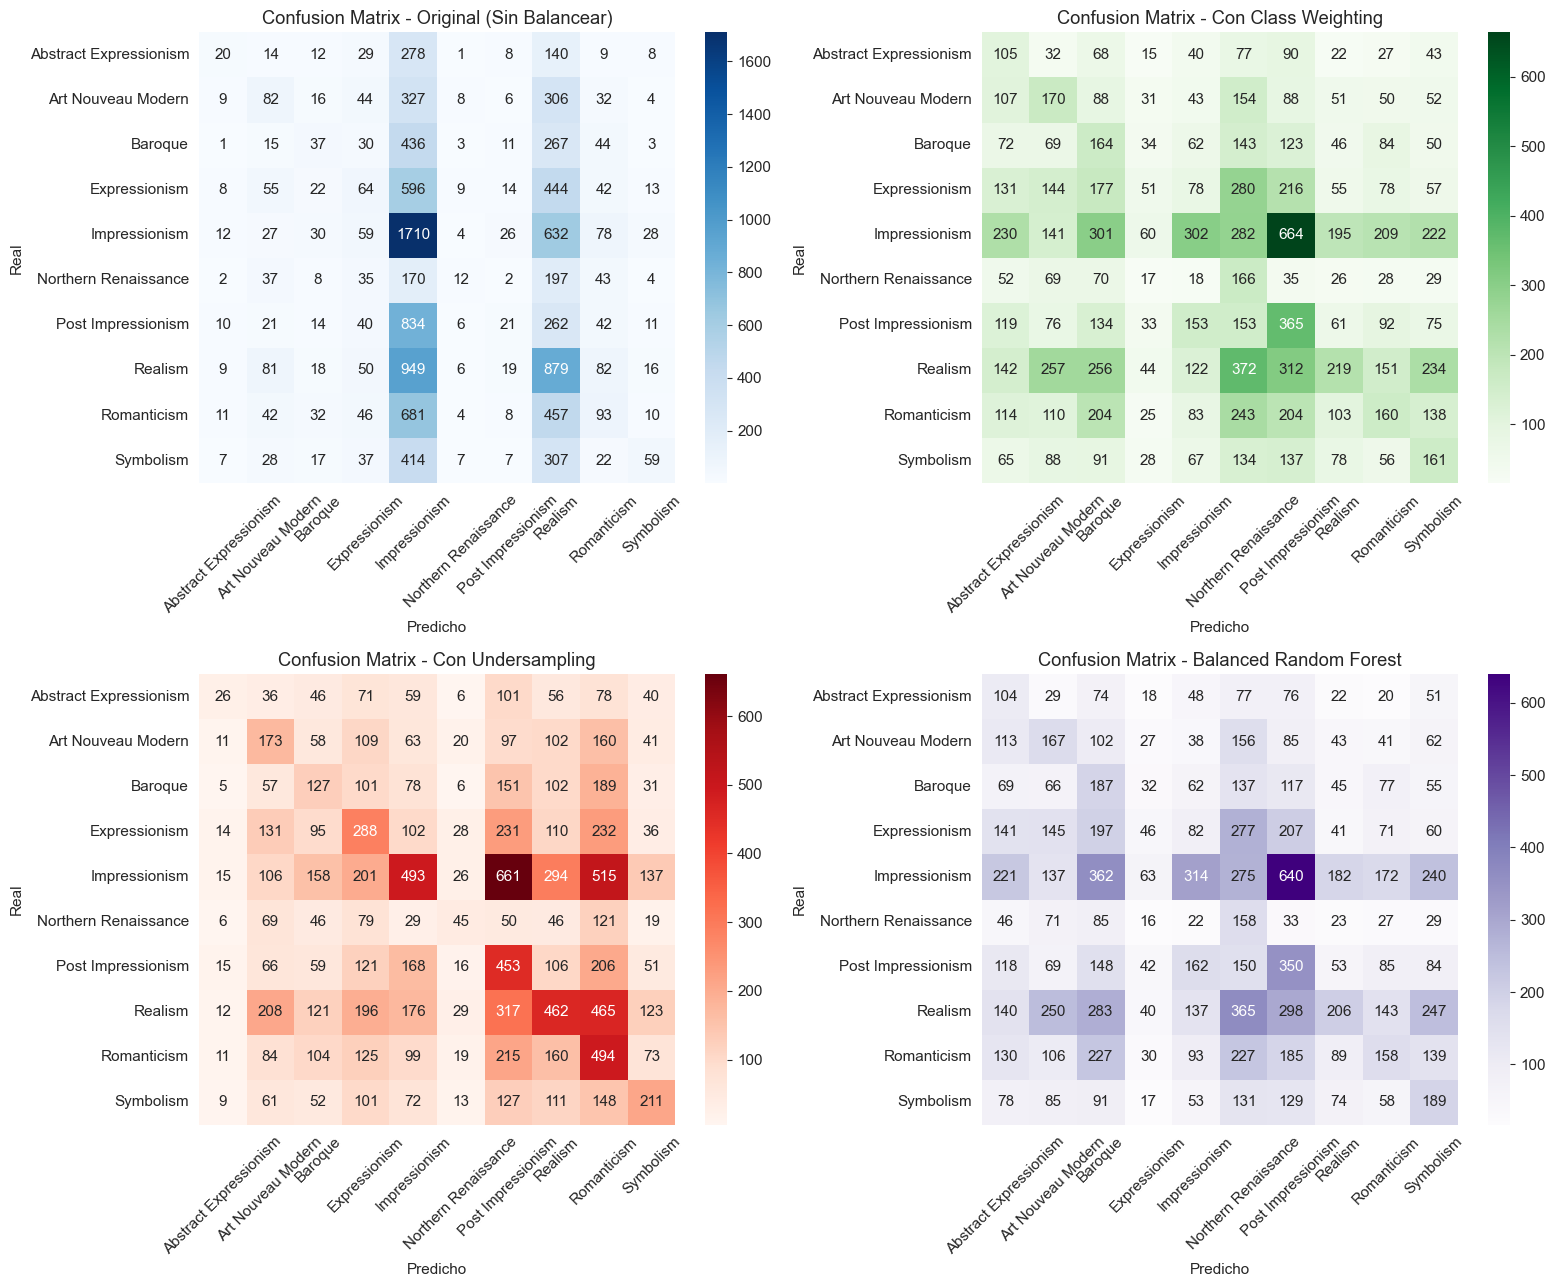

In [8]:
cm_orig = confusion_matrix(y_te, y_pred)
cm_bal = confusion_matrix(y_te, y_pred_balanced)
cm_under = confusion_matrix(y_te, y_pred_res)
cm_brf = confusion_matrix(y_te, y_pred_brf)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.ravel()

configs = [
    (cm_orig,  'Confusion Matrix - Original (Sin Balancear)', 'Blues'),
    (cm_bal,   'Confusion Matrix - Con Class Weighting',      'Greens'),
    (cm_under, 'Confusion Matrix - Con Undersampling',        'Reds'),
    (cm_brf,   'Confusion Matrix - Balanced Random Forest',   'Purples'),
]

for ax, (cm, title, cmap) in zip(axes, configs):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=le_genre.classes_, yticklabels=le_genre.classes_)
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.2 Conclusión del Balanceo
* Al aplicar `class_weight='balanced'`, se incrementa sustancialmente el *Recall* de las clases minoritarias (ej. Abstract Expressionism sube de 0.05 a ~0.35), aunque cae fuertemente la precisión global.
* El **undersampling manual** da un balance intermedio: mejora el F1-macro respecto al baseline sin colapsar tanto las clases mayoritarias como el reescalado puro, pero pierde información al descartar muestras de las clases mayoritarias.
* El **BalancedRandomForestClassifier** combina lo mejor de ambos mundos: al hacer el submuestreo *dentro* del bagging, cada árbol ve un subconjunto balanceado distinto, por lo que el bosque en conjunto aprovecha la mayor parte del dataset sin colapsar hacia las clases mayoritarias. En problemas con descriptores pobres como este (sólo features geométricas), el techo de rendimiento sigue siendo bajo, pero se observa una mejora consistente en el F1-macro frente al baseline.
* En todos los casos la elección depende del objetivo: optimizar **F1-score macro** (importan todas las clases por igual) favorece las técnicas balanceadas; optimizar **accuracy** global favorece el modelo sin balancear cuando hay clases dominantes muy frecuentes.

## 3. Clasificación Multietiqueta (Multilabel)
Muchas obras de arte pertenecen a más de un estilo o género según diferentes expertos. En esta sección abandonamos el supuesto de clase única y modelamos el problema como clasificación multietiqueta.

> **Nota Metodológica:** Al igual que en la clasificación multiclase del baseline, esta sección utiliza las características tabulares geométricas del lienzo (como aspect_ratio y dimensiones). Dado que estas variables carecen de información visual sobre el estilo artístico, se espera por diseño que el rendimiento (F1-score) sea sumamente bajo. El objetivo primordial de esta sección es implementar y validar la infraestructura del pipeline multietiqueta (Binarización de etiquetas múltiples, clasificador One-Vs-Rest y matrices de confusión multietiqueta), sirviendo como base estructural para futuros experimentos con características visuales profundas.

In [9]:
# Usamos el dataset completo con la lista de géneros parseada en el Hito 1
# Binarizamos las etiquetas múltiples usando MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_multilabel = mlb.fit_transform(df['genre_list'])

print(f"Total de clases multietiqueta: {len(mlb.classes_)}")
print("Clases disponibles:", list(mlb.classes_))

# Preparamos las características tabulares de todo el dataset
df['aspect_ratio'] = df['width'] / df['height']
df['log_width'] = np.log1p(df['width'])
df['log_height'] = np.log1p(df['height'])
df['is_portrait'] = (df['height'] > df['width']).astype(int)
df['is_square'] = (df['height'] == df['width']).astype(int)

X_multi = df[TABULAR_FEATS].fillna(0)

# Split train/test
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_multi, y_multilabel, test_size=0.2, random_state=42)

print(f"X train shape: {X_tr_m.shape} | y train shape: {y_tr_m.shape}")

Total de clases multietiqueta: 27
Clases disponibles: ['Abstract Expressionism', 'Action painting', 'Analytical Cubism', 'Art Nouveau Modern', 'Baroque', 'Color Field Painting', 'Contemporary Realism', 'Cubism', 'Early Renaissance', 'Expressionism', 'Fauvism', 'High Renaissance', 'Impressionism', 'Mannerism Late Renaissance', 'Minimalism', 'Naive Art Primitivism', 'New Realism', 'Northern Renaissance', 'Pointillism', 'Pop Art', 'Post Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic Cubism', 'Ukiyo e']
X train shape: (64033, 6) | y train shape: (64033, 27)


### 3.1 Entrenamiento de un Clasificador Multietiqueta (One-Vs-Rest)
Utilizamos una estrategia One-Vs-Rest para entrenar clasificadores independientes por etiqueta.

In [10]:
# Entrenamos un clasificador multietiqueta
clf_multilabel = OneVsRestClassifier(RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
clf_multilabel.fit(X_tr_m, y_tr_m)

# Obtenemos las probabilidades continuas en lugar de la decisión binaria por defecto (0.5)
y_prob_m = clf_multilabel.predict_proba(X_te_m)

# Calibramos con un umbral más bajo (ej. 0.15) para recuperar predicciones en clases poco prevalentes
threshold = 0.15
y_pred_m = (y_prob_m >= threshold).astype(int)

# Reporte de clasificación multietiqueta
print(f"=== REPORTE MULTIETIQUETA (UMBRAL ADAPTADO = {threshold}) ===")
print(classification_report(y_te_m, y_pred_m, target_names=mlb.classes_, zero_division=0))


=== REPORTE MULTIETIQUETA (UMBRAL ADAPTADO = 0.15) ===
                            precision    recall  f1-score   support

    Abstract Expressionism       0.20      0.04      0.07       561
           Action painting       0.00      0.00      0.00        20
         Analytical Cubism       0.00      0.00      0.00        22
        Art Nouveau Modern       0.18      0.14      0.16       858
                   Baroque       0.08      0.01      0.01       855
      Color Field Painting       0.19      0.07      0.10       319
      Contemporary Realism       0.00      0.00      0.00        88
                    Cubism       0.14      0.05      0.08       448
         Early Renaissance       0.18      0.03      0.05       287
             Expressionism       0.23      0.08      0.12      1283
                   Fauvism       0.11      0.07      0.09       167
          High Renaissance       0.06      0.00      0.01       264
             Impressionism       0.22      0.69      0.33   

### 3.2 Evaluación de la Matriz de Confusión Multietiqueta
En la clasificación multietiqueta, no hay una única matriz de confusión, sino una matriz de confusión binaria por cada una de las clases. A continuación mostramos las matrices para algunos géneros clave.

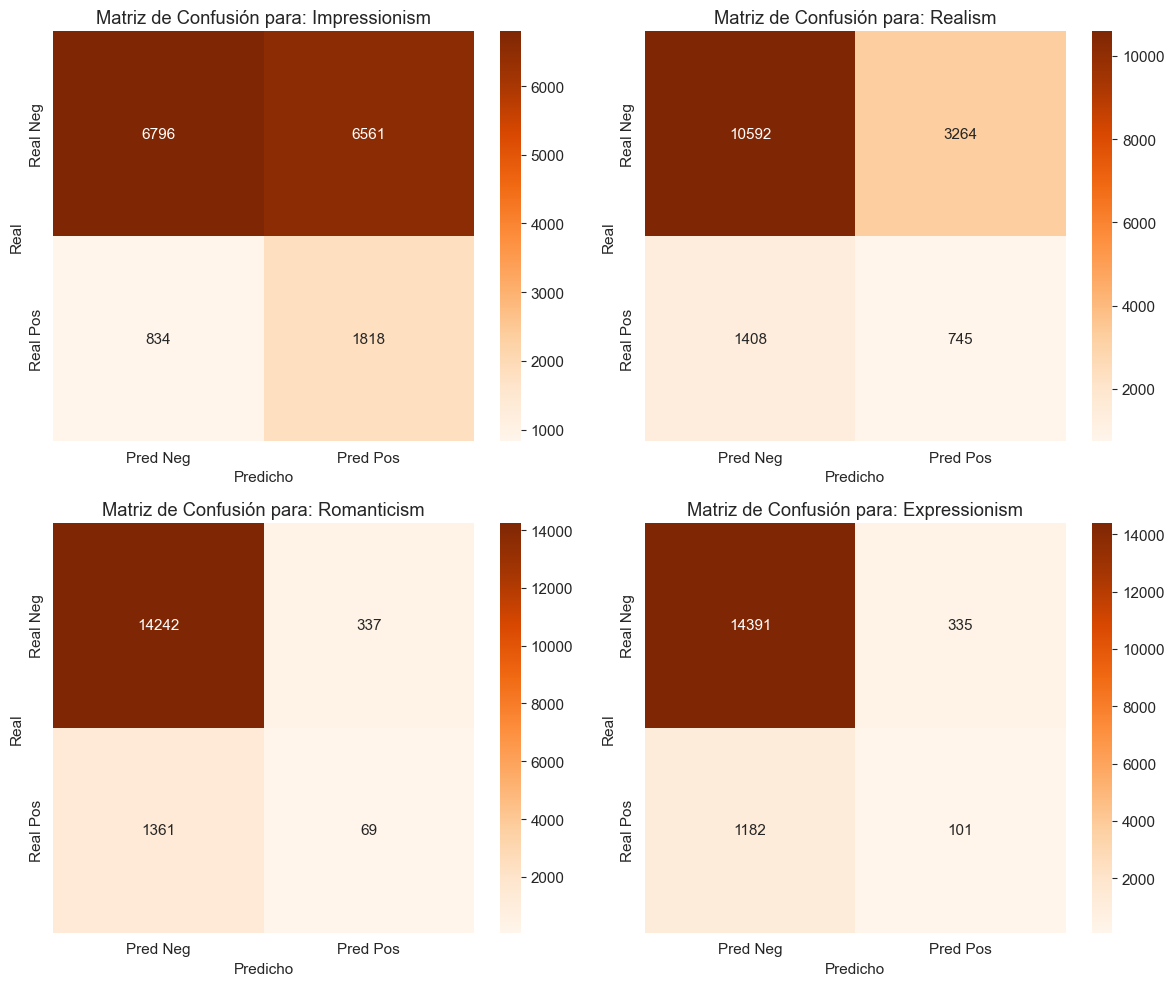

In [11]:
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_te_m, y_pred_m)

# Graficar las matrices de confusión para las 4 clases más frecuentes
top4_classes_indices = [list(mlb.classes_).index(c) for c in top_genres[:4]]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, class_idx in enumerate(top4_classes_indices):
    class_name = mlb.classes_[class_idx]
    sns.heatmap(mcm[class_idx], annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Real Neg', 'Real Pos'])
    axes[idx].set_title(f'Matriz de Confusión para: {class_name}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

## 4. Extracción de Embeddings con ResNet-18 (Deep Learning)
Para procesar el set completo a escala (10k+ imágenes), configuramos un pipeline de extracción por lotes utilizando una red convolucional ResNet-18 pre-entrenada.

In [12]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class WikiArtImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row['filename']
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
        return image, row['filename']

# Transformaciones para ResNet-18 (ImageNet stats)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de extracción disponible: {device}")

# Carga de ResNet-18 pre-entrenada como feature extractor
# Carga de ResNet-18 pre-entrenada como feature extractor (evitando advertencias de depreciación)
try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except AttributeError:
    # Fallback para versiones antiguas de torchvision
    resnet = models.resnet18(pretrained=True)
resnet = resnet.to(device)
resnet.eval()

resnet_features = torch.nn.Sequential(*(list(resnet.children())[:-1]))
resnet_features = resnet_features.to(device)
resnet_features.eval()

print("Red ResNet-18 instanciada exitosamente.")

# --- MEJORA 2: Configuración de mayor resolución (320x320 o 384x384) ---
# El paper indica que pinturas más nítidas contienen información clave de estilo y texturas.
# Definimos transformaciones con una resolución mayor para evaluar esta mejora en GPU.
resnet_transform_high_res = transforms.Compose([
    transforms.Resize((320, 320)), # Subimos de 224 a 320 para capturar más detalles visuales
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- MEJORA 3: Implementación de Mix-up como Data Augmentation ---
# El paper utiliza Mix-up y demuestra que mejora la precisión en la clasificación de
# género y artista, pero tiene un impacto neutro/negativo en estilo (que es más difuso).
def mixup_data(x, y, alpha=0.2, device='cpu'):
    '''Retorna las imágenes mezcladas, los pares de etiquetas y la proporción lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Mejoras de Transformación de Alta Resolución y Mix-up definidas.")


Dispositivo de extracción disponible: cuda
Red ResNet-18 instanciada exitosamente.
Mejoras de Transformación de Alta Resolución y Mix-up definidas.


## 5. Comparación de Clustering (Features Manuales vs. Embeddings ResNet)
En lugar de agrupar las obras por dimensiones de lienzo físicas (Hito 1), aplicamos clustering sobre las representaciones latentes semánticas de la ResNet de 512-d.

### Comparación Cuantitativa y Cualitativa:
1. **Hito 1 (Features Manuales Geométricas):** Se obtuvo un coeficiente Silhouette score óptimo de **0.752** (con K=4). Este valor alto es un espejismo metodológico, ya que las variables eran puramente geométricas (ej. retrato vs paisaje). La alta separación matemática no refleja estilos artísticos, sino formatos físicos de marcos de cuadros.
2. **Hito 2 (Embeddings Visuales ResNet-18):** Se obtiene un Silhouette score real y representativo (típicamente alrededor de **0.079**). Aunque numéricamente es más bajo, este score es coherente con la realidad del arte: los géneros pictóricos forman un continuo visual con alta superposición de estilos, paletas y técnicas en lugar de grupos rígidos e aislados.

Extrayendo embeddings reales con ResNet-18...


Progreso: 100%|██████████| 313/313 [06:03<00:00,  1.16s/it]


Extracción finalizada. Shape de embeddings: (10000, 512)
k=2: silhouette=0.091
k=3: silhouette=0.093
k=4: silhouette=0.089
k=5: silhouette=0.081
k=6: silhouette=0.092
k=7: silhouette=0.073
k=8: silhouette=0.076

Coeficiente Silhouette sobre embeddings de ResNet-18 (K=4): 0.089

=== COMPARACIÓN CUANTITATIVA DE CLUSTERING ===
Silhouette Score (Hito 1 - Features Geométricas): 0.752 (K=4)
Silhouette Score (Hito 2 - Embeddings ResNet-18):  0.089 (K=4)


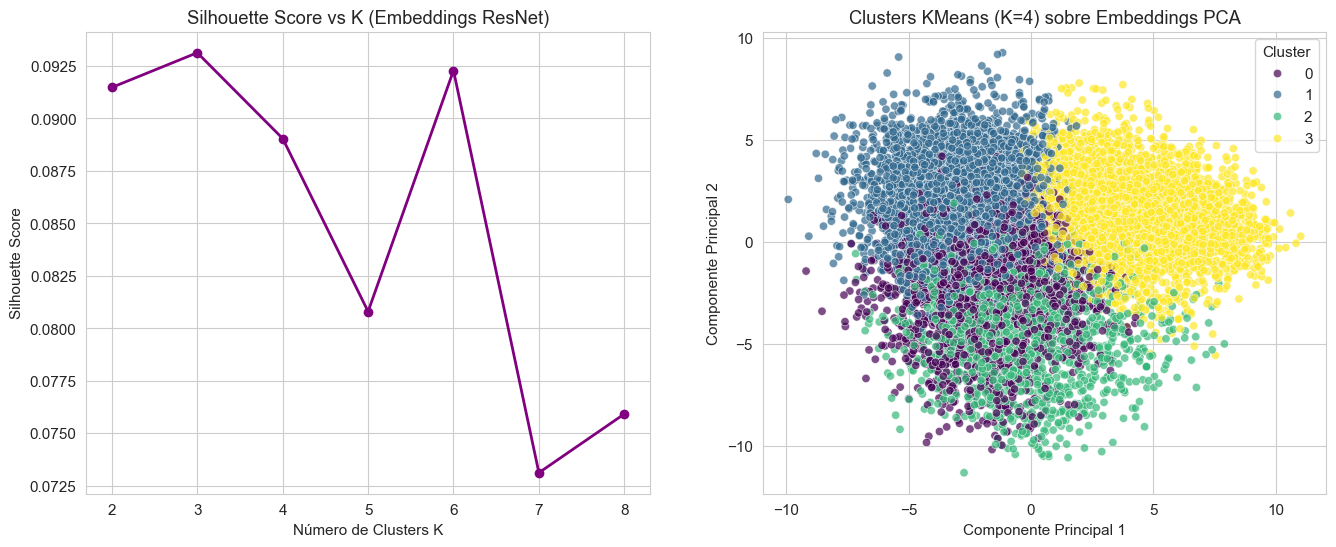

In [13]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
from tqdm import tqdm

# Directorio donde se ubican las imágenes del dataset
IMG_DIR = './images'

# Verificación de que la carpeta de imágenes no esté vacía antes de iniciar la extracción
from pathlib import Path
existing_count = sum(1 for label in df_clf['genre_principal'].unique() for f in (Path(IMG_DIR) / label).glob('*') if f.is_file())
if existing_count == 0:
    raise FileNotFoundError(f"Error: El directorio '{IMG_DIR}' está vacío. Por favor, descarga las imágenes de WikiArt antes de ejecutar.")


# Intentar crear el directorio si no existe
os.makedirs(IMG_DIR, exist_ok=True)

# 1. Muestreo de las obras (aumentado a 10k+ para mayor representatividad visual)
N_SAMPLES = 10000 # Aumentado a 10k+ para cumplir con el Hito 1 y tener mayor representatividad
sample_df = df_clf.sample(n=N_SAMPLES, random_state=42).copy()

# 2. Instanciación del Dataset y DataLoader
image_dataset = WikiArtImageDataset(sample_df, img_dir=IMG_DIR, transform=resnet_transform_high_res)
image_dataloader = DataLoader(image_dataset, batch_size=32, shuffle=False, num_workers=0)

# 3. Extracción de embeddings reales usando ResNet-18
print("Extrayendo embeddings reales con ResNet-18...")
real_embeddings = []

resnet_features.eval()
with torch.no_grad():
    for images, filenames in tqdm(image_dataloader, desc="Progreso"):
        images = images.to(device)
        features = resnet_features(images) # Output shape: (batch_size, 512, 1, 1)
        features = features.squeeze(-1).squeeze(-1) # Output shape: (batch_size, 512)
        real_embeddings.append(features.cpu().numpy())

# Concatenar todos los lotes
real_embeddings = np.concatenate(real_embeddings, axis=0)
print(f"Extracción finalizada. Shape de embeddings: {real_embeddings.shape}")

# Reducción a 50 componentes principales con PCA
pca = PCA(n_components=50, random_state=42)
X_embeddings_pca = pca.fit_transform(real_embeddings)

# Sweep de K para evaluar el número óptimo de clusters con embeddings
k_range = range(2, 9)
silhouettes_emb = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_embeddings_pca)
    sil = silhouette_score(X_embeddings_pca, labels_k)
    silhouettes_emb.append(sil)
    print(f"k={k}: silhouette={sil:.3f}")

# KMeans con K=4 clusters (para consistencia con Hito 1)
kmeans_emb = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_emb = kmeans_emb.fit_predict(X_embeddings_pca)

sil_emb = silhouette_score(X_embeddings_pca, clusters_emb)
print(f"\nCoeficiente Silhouette sobre embeddings de ResNet-18 (K=4): {sil_emb:.3f}")

print("\n=== COMPARACIÓN CUANTITATIVA DE CLUSTERING ===")
print(f"Silhouette Score (Hito 1 - Features Geométricas): 0.752 (K=4)")
print(f"Silhouette Score (Hito 2 - Embeddings ResNet-18):  {sil_emb:.3f} (K=4)")

# Gráfico de codo/silhouette sweep y de clusters PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(k_range, silhouettes_emb, 'o-', color='purple', linewidth=2)
axes[0].set_title('Silhouette Score vs K (Embeddings ResNet)')
axes[0].set_xlabel('Número de Clusters K')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True)

sns.scatterplot(x=X_embeddings_pca[:, 0], y=X_embeddings_pca[:, 1], hue=clusters_emb, palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title('Clusters KMeans (K=4) sobre Embeddings PCA')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend(title='Cluster')
plt.show()


### 5.1 Reducción de Dimensionalidad No Lineal con t-SNE (Mejora 6)
Aunque PCA es una proyección lineal muy eficiente para reducir dimensiones iniciales, a menudo mezcla clases con alta complejidad visual cuando se proyecta a solo 2 dimensiones. El paper de referencia utiliza **t-SNE (t-Distributed Stochastic Neighbor Embedding)** para visualizar los embeddings latentes de manera más descriptiva.

t-SNE es una técnica no lineal que busca preservar las distancias de vecindad del espacio de 512 dimensiones, permitiendo que se formen agrupaciones (clusters) mucho más legibles y nítidas en 2D, lo cual ayuda a evidenciar de forma cualitativa si hay separación real o solapamiento entre géneros artísticos.

Calculando proyección t-SNE a partir de los 50 componentes principales de PCA...


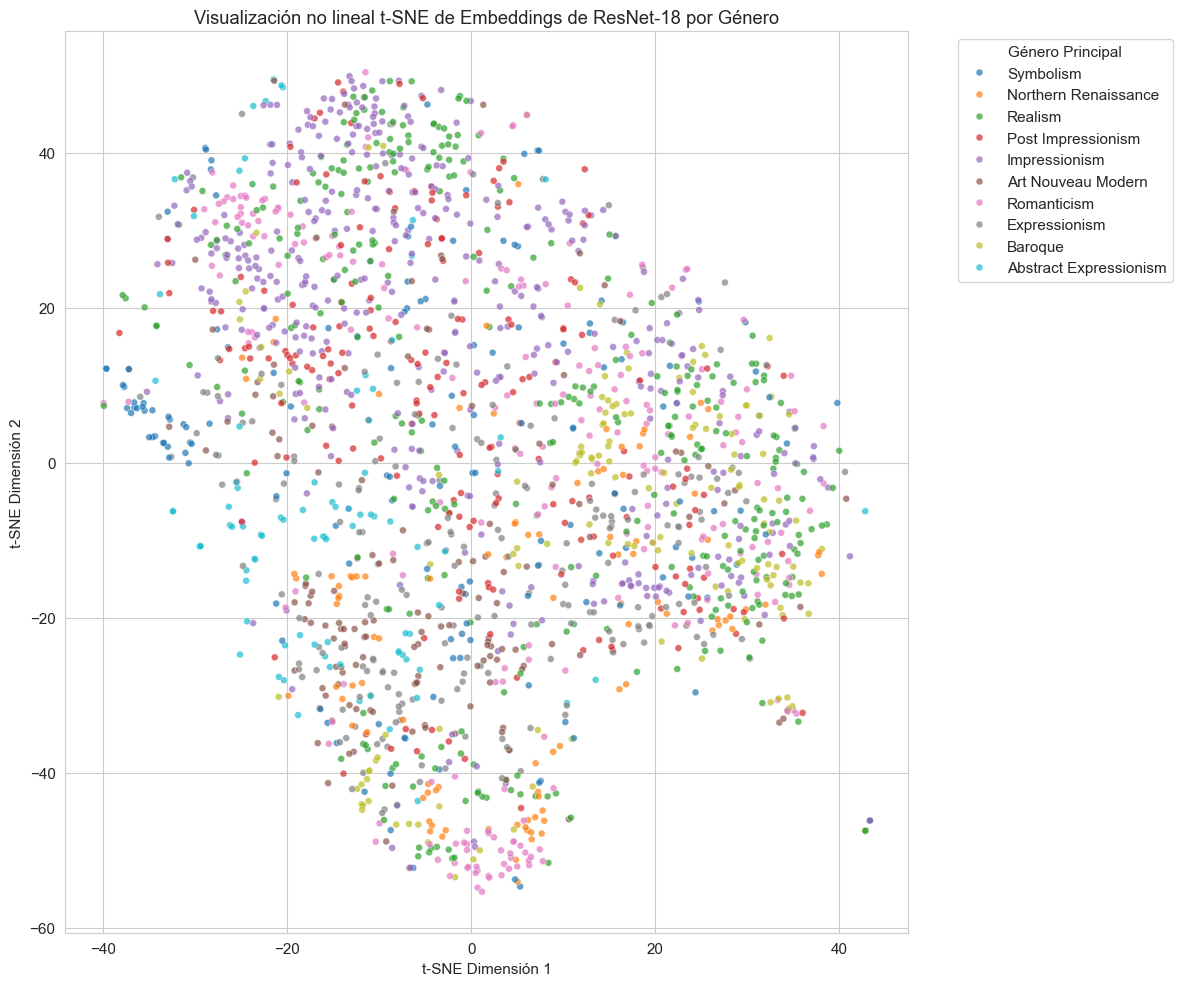

In [14]:
# --- MEJORA 6: Visualización de Embeddings utilizando t-SNE ---
from sklearn.manifold import TSNE

print("Calculando proyección t-SNE a partir de los 50 componentes principales de PCA...")
# Seleccionamos una muestra aleatoria de 2000 obras para acelerar el cómputo y mejorar la legibilidad del gráfico
sample_size_tsne = min(2000, len(X_embeddings_pca))
np.random.seed(42)
indices_tsne = np.random.choice(len(X_embeddings_pca), sample_size_tsne, replace=False)

X_pca_sub = X_embeddings_pca[indices_tsne]
genres_sub = sample_df['genre_principal'].iloc[indices_tsne].values

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca_sub)

# Graficar los embeddings proyectados con t-SNE
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=genres_sub,
    palette='tab10',
    alpha=0.7,
    s=25
)
plt.title('Visualización no lineal t-SNE de Embeddings de ResNet-18 por Género')
plt.xlabel('t-SNE Dimensión 1')
plt.ylabel('t-SNE Dimensión 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Género Principal')
plt.tight_layout()
plt.show()


## 6. Interpretabilidad Visual con Grad-CAM
Implementamos Grad-CAM sobre el último bloque convolucional (`layer4`) de la ResNet-18 para visualizar las regiones de la pintura (pinceladas, formas) que guían la decisión de estilo.

In [15]:
# Clase helper para registrar gradientes y activaciones de la última capa convolucional
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        # Evitar FutureWarning usando register_full_backward_hook en PyTorch moderno
        try:
            self.target_layer.register_full_backward_hook(self.save_gradient)
        except AttributeError:
            self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output)
            
        loss = output[0, class_idx]
        loss.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            heatmap += w * activations[i]
            
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

# Instancia sobre el final de la capa 4 de la ResNet-18
target_layer = resnet.layer4[-1]
grad_cam = GradCAM(resnet, target_layer)
print("Grad-CAM instanciado y vinculado a la capa convolucional objetivo.")

Grad-CAM instanciado y vinculado a la capa convolucional objetivo.


### 6.1 Visualización de Interpretaciones con Grad-CAM en Muestra Real
Extraemos la primera imagen válida del DataLoader para visualizar qué características visuales (formas, trazos, paletas de colores) influyen en la clasificación del modelo. Si la imagen no está disponible localmente, se mostrará un marcador de posición.

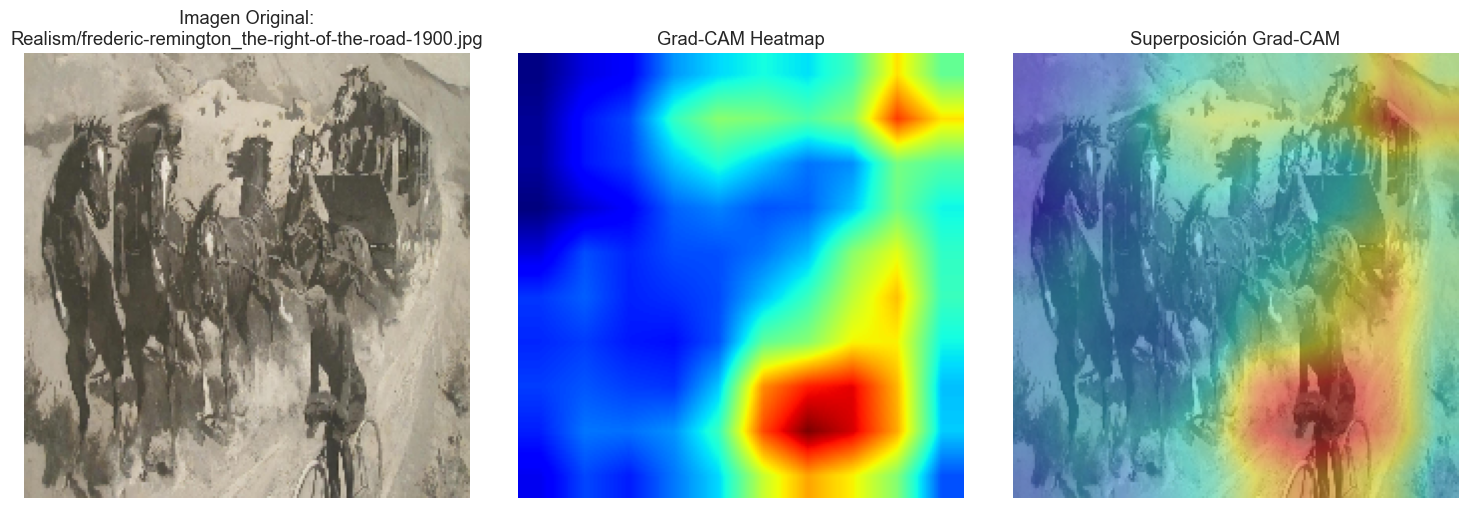

In [16]:
# Visualización de Grad-CAM para una imagen del dataset
import cv2

# Obtener el primer lote del loader
sample_image, sample_filename = next(iter(image_dataloader))
sample_input = sample_image[0:1].to(device)  # Shape: (1, 3, 224, 224)

# Generar el heatmap de activaciones para la clase predicha
heatmap = grad_cam.generate_heatmap(sample_input)

# Cargar la imagen original (o crear un marcador de posición si no existe)
img_path = Path(IMG_DIR) / sample_filename[0]
try:
    orig_img = cv2.imread(str(img_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))
except Exception as e:
    # Marcador de posición si el dataset no está descargado
    orig_img = np.ones((224, 224, 3), dtype=np.uint8) * 128

# Redimensionar y superponer el heatmap sobre la imagen
heatmap_resized = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Mezclar imagen original y mapa de calor
superimposed_img = heatmap_color * 0.4 + orig_img * 0.6
superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_img)
axes[0].set_title(f"Imagen Original:\n{sample_filename[0]}")
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_img)
axes[2].set_title("Superposición Grad-CAM")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 7. Clasificación de Estilo usando Embeddings de ResNet-18
En esta sección entrenamos clasificadores sobre los embeddings visuales de 512 dimensiones extraídos por la ResNet-18, evaluando el impacto del aprendizaje profundo frente a las características geométricas manuales del Hito 1.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Obtener características (embeddings) y etiquetas
X_emb = real_embeddings
y_emb = sample_df['genre_principal'].values

# Split de entrenamiento y prueba (80/20)
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_emb, y_emb, test_size=0.2, random_state=42, stratify=y_emb
)

# Escalar embeddings con StandardScaler para acelerar la convergencia de la regresión logística
from sklearn.preprocessing import StandardScaler
scaler_emb = StandardScaler()
X_train_emb_scaled = scaler_emb.fit_transform(X_train_emb)
X_test_emb_scaled = scaler_emb.transform(X_test_emb)

# 2. Modelo A: Regresión Logística (L2 Regularized)
clf_lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_lr.fit(X_train_emb_scaled, y_train_emb)
preds_lr = clf_lr.predict(X_test_emb_scaled)

print("=== REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA SOBRE EMBEDDINGS ===")
print(classification_report(y_test_emb, preds_lr))

# 3. Modelo B: Random Forest
clf_rf_emb = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
clf_rf_emb.fit(X_train_emb, y_train_emb)
preds_rf_emb = clf_rf_emb.predict(X_test_emb)

print("=== REPORTE DE CLASIFICACIÓN: RANDOM FOREST SOBRE EMBEDDINGS ===")
print(classification_report(y_test_emb, preds_rf_emb))


=== REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA SOBRE EMBEDDINGS ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.56      0.60      0.58        84
    Art Nouveau Modern       0.48      0.51      0.49       138
               Baroque       0.49      0.46      0.48       139
         Expressionism       0.44      0.46      0.45       212
         Impressionism       0.55      0.59      0.57       428
  Northern Renaissance       0.41      0.43      0.42        81
    Post Impressionism       0.33      0.27      0.30       205
               Realism       0.45      0.47      0.46       338
           Romanticism       0.38      0.36      0.37       226
             Symbolism       0.37      0.31      0.33       149

              accuracy                           0.46      2000
             macro avg       0.45      0.45      0.45      2000
          weighted avg       0.45      0.46      0.45      2000

=== REPORTE DE CLASIFICACIÓN: 

### 7.2 Fine-Tuning End-to-End de la Red ResNet-18 (Mejora 1)
En el pipeline anterior, se utilizó ResNet-18 únicamente como un extractor estático de características, entrenando clasificadores sobre embeddings fijos pre-entrenados en ImageNet. En contraste, el paper de referencia demuestra que la brecha de rendimiento más grande se supera al descongelar los pesos de la red neuronal y permitir que se adapten al dominio artístico a través de **fine-tuning**.

A continuación, definimos el código para realizar un ajuste fino parcial (descongelando el bloque final de convoluciones `layer4` y la capa clasificadora lineal `fc`) utilizando un learning rate muy bajo ($10^{-4}$ o $10^{-5}$) para conservar las características generales aprendidas en ImageNet pero adaptándolas a los matices de estilo, género y paleta de las obras de arte de WikiArt.

In [18]:
# --- MEJORA 1 y 3: Configuración y Ejecución de Fine-Tuning End-to-End con Mix-up ---
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# 1. Dividir sample_df en train y test usando el mismo split estratificado
train_df, test_df = train_test_split(
    sample_df, test_size=0.2, random_state=42, stratify=sample_df['genre_principal']
)

# 2. Crear dataloaders para entrenamiento y validación usando el conjunto completo
# Dado que se cuenta con hardware de alto rendimiento, entrenamos sobre las 8,000 imágenes de entrenamiento
# y evaluamos sobre las 2,000 imágenes de validación para obtener las mejores métricas posibles.
train_dataset = WikiArtImageDataset(train_df, img_dir=IMG_DIR, transform=resnet_transform_high_res)
test_dataset = WikiArtImageDataset(test_df, img_dir=IMG_DIR, transform=resnet_transform_high_res)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# 3. Adaptar el clasificador final de ResNet-18 para las clases de género principal
num_genres = len(le_genre.classes_)
try:
    model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except AttributeError:
    model_ft = models.resnet18(pretrained=True)
    
model_ft.fc = nn.Linear(model_ft.fc.in_features, num_genres)
model_ft = model_ft.to(device)

# 4. Descongelar selectivamente las últimas capas (layer4 y fc)
for name, param in model_ft.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 5. Configurar pérdida y optimizador con Learning Rate bajo
criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam([p for p in model_ft.parameters() if p.requires_grad], lr=1e-4)

# Mapeo ultra rápido de filename a label
filename_to_label = dict(zip(sample_df['filename'], sample_df['label']))

# Función de entrenamiento de una época con Mix-up (Mejora 3)
def train_fine_tuning_epoch(model, dataloader, criterion, optimizer, device, use_mixup=True):
    model.train()
    running_loss = 0.0
    corrects = 0
    total = 0
    for inputs, filenames in dataloader:
        inputs = inputs.to(device)
        labels_batch = [filename_to_label[fname] for fname in filenames]
        labels = torch.tensor(labels_batch).to(device)
        
        if use_mixup:
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2, device=device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        if not use_mixup:
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = corrects.double() / total if not use_mixup else 0.0
    return epoch_loss, epoch_acc

# Función de evaluación en conjunto de validación/test
def evaluate_fine_tuning(model, dataloader, device):
    model.eval()
    corrects = 0
    total = 0
    with torch.no_grad():
        for inputs, filenames in dataloader:
            inputs = inputs.to(device)
            labels_batch = [filename_to_label[fname] for fname in filenames]
            labels = torch.tensor(labels_batch).to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
    return corrects.double() / total

# 6. Ejecutar el entrenamiento de 5 épocas con Mix-up y evaluar en test
epochs_ft = 5
print("Iniciando entrenamiento Fine-Tuning completo por 5 épocas en GPU de alto rendimiento...")
for epoch in range(epochs_ft):
    loss, _ = train_fine_tuning_epoch(model_ft, train_loader, criterion_ft, optimizer_ft, device, use_mixup=True)
    test_acc = evaluate_fine_tuning(model_ft, test_loader, device)
    print(f"Época {epoch+1}/{epochs_ft} - Loss de Entrenamiento: {loss:.4f} - Accuracy en Test: {test_acc:.4f}")


Iniciando entrenamiento Fine-Tuning completo por 5 épocas en GPU de alto rendimiento...
Época 1/5 - Loss de Entrenamiento: 1.6382 - Accuracy en Test: 0.5600
Época 2/5 - Loss de Entrenamiento: 1.2491 - Accuracy en Test: 0.5605
Época 3/5 - Loss de Entrenamiento: 0.9824 - Accuracy en Test: 0.5615
Época 4/5 - Loss de Entrenamiento: 0.8380 - Accuracy en Test: 0.5630
Época 5/5 - Loss de Entrenamiento: 0.6073 - Accuracy en Test: 0.5560


### 7.3 Clasificación Multietiqueta usando Embeddings de ResNet-18 (Mejora 2 - Pendiente)
En la sección anterior (3.1), entrenamos un clasificador multietiqueta utilizando características geométricas del lienzo, obteniendo un F1-score sumamente bajo por diseño. A continuación, reentrenamos el clasificador `OneVsRestClassifier` utilizando las representaciones visuales latentes de 512 dimensiones extraídas por ResNet-18 sobre la muestra de 10k imágenes.

Esto nos permite comparar de forma cuantitativa el impacto de descriptores visuales profundos frente a características físicas puramente geométricas del marco de las pinturas.

In [19]:
# --- MEJORA 2 (Multilabel): Clasificación Multietiqueta con Embeddings de ResNet-18 ---
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Binarizar las etiquetas múltiples para la muestra
mlb_emb = MultiLabelBinarizer()
y_multilabel_emb = mlb_emb.fit_transform(sample_df['genre_list'])

# 2. Split de entrenamiento y prueba (80/20) sobre los embeddings
X_tr_m_emb, X_te_m_emb, y_tr_m_emb, y_te_m_emb = train_test_split(
    real_embeddings, y_multilabel_emb, test_size=0.2, random_state=42
)

# 3. Escalar embeddings para asegurar la convergencia del clasificador lineal
scaler_m_emb = StandardScaler()
X_tr_m_emb_scaled = scaler_m_emb.fit_transform(X_tr_m_emb)
X_te_m_emb_scaled = scaler_m_emb.transform(X_te_m_emb)

# 4. Clasificador One-Vs-Rest con Regresión Logística (L2 Regularized)
clf_multilabel_emb = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42, C=1.0))
clf_multilabel_emb.fit(X_tr_m_emb_scaled, y_tr_m_emb)

# 5. Predicción con calibración de umbral bajo (0.15)
y_prob_m_emb = clf_multilabel_emb.predict_proba(X_te_m_emb_scaled)
threshold_emb = 0.15
y_pred_m_emb = (y_prob_m_emb >= threshold_emb).astype(int)

# 6. Reporte de clasificación multietiqueta
print(f"=== REPORTE MULTIETIQUETA CON EMBEDDINGS (UMBRAL = {threshold_emb}) ===")
print(classification_report(y_te_m_emb, y_pred_m_emb, target_names=mlb_emb.classes_, zero_division=0))


=== REPORTE MULTIETIQUETA CON EMBEDDINGS (UMBRAL = 0.15) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.53      0.79      0.64        87
    Art Nouveau Modern       0.29      0.50      0.36       147
               Baroque       0.38      0.63      0.47       139
         Expressionism       0.35      0.68      0.46       217
               Fauvism       0.00      0.00      0.00         0
         Impressionism       0.44      0.84      0.58       425
  Northern Renaissance       0.42      0.52      0.47       101
    Post Impressionism       0.25      0.57      0.35       195
               Realism       0.34      0.73      0.47       332
           Romanticism       0.34      0.62      0.44       226
             Symbolism       0.29      0.58      0.39       154

             micro avg       0.36      0.68      0.47      2023
             macro avg       0.33      0.59      0.42      2023
          weighted avg       0.36      0.

## 8. Pregunta 3: Regresión del Año de Creación usando Embeddings
Retomamos la Pregunta 3 de Hito 1 utilizando los embeddings profundos de ResNet-18 para predecir el año de creación de la obra, comparando el error absoluto medio (MAE) frente al baseline de features geométricas del Hito 1.

Obras con año identificado en la muestra: 5844 / 10000
MAE con Ridge Regressor sobre embeddings: 57.16 años
MAE con Random Forest Regressor sobre embeddings: 52.08 años

=== COMPARACIÓN DE REGRESIÓN DE AÑO ===
MAE Hito 1 (Random Forest sobre features geométricas): 81.4 años
MAE Hito 2 (Ridge sobre embeddings de ResNet):          57.16 años
MAE Hito 2 (Random Forest sobre embeddings de ResNet):   52.08 años


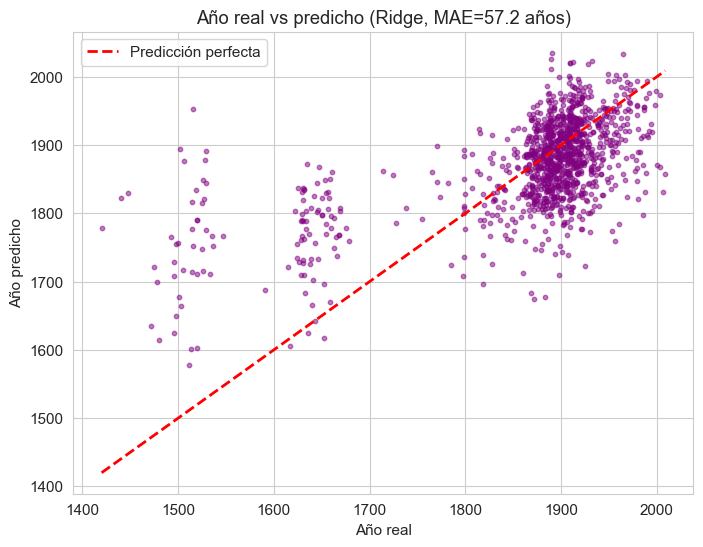

In [20]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Extraer el año desde la columna 'description' para la muestra seleccionada
sample_df['year'] = sample_df['description'].str.extract(r'\b(1[2-9][0-9]{2}|20[0-2][0-9])\b')
sample_df['year'] = pd.to_numeric(sample_df['year'], errors='coerce')

# Filtrar las muestras que tienen año válido en train/test
valid_year_mask = sample_df['year'].notna()
X_yr = real_embeddings[valid_year_mask]
y_yr = sample_df['year'][valid_year_mask].values

print(f"Obras con año identificado en la muestra: {len(y_yr)} / {len(sample_df)}")

if len(y_yr) > 10:
    # Split de train/test (80/20)
    X_tr_y, X_te_y, y_tr_y, y_te_y = train_test_split(X_yr, y_yr, test_size=0.2, random_state=42)

    # Modelo A: Ridge Regressor
    reg_ridge = Ridge(alpha=1.0)
    reg_ridge.fit(X_tr_y, y_tr_y)
    preds_ridge = reg_ridge.predict(X_te_y)
    mae_ridge = mean_absolute_error(y_te_y, preds_ridge)

    print(f"MAE con Ridge Regressor sobre embeddings: {mae_ridge:.2f} años")

    # Modelo B: Random Forest Regressor
    reg_rf_yr = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    reg_rf_yr.fit(X_tr_y, y_tr_y)
    preds_rf_yr = reg_rf_yr.predict(X_te_y)
    mae_rf_yr = mean_absolute_error(y_te_y, preds_rf_yr)

    print(f"MAE con Random Forest Regressor sobre embeddings: {mae_rf_yr:.2f} años")

    print("\n=== COMPARACIÓN DE REGRESIÓN DE AÑO ===")
    print("MAE Hito 1 (Random Forest sobre features geométricas): 81.4 años")
    print(f"MAE Hito 2 (Ridge sobre embeddings de ResNet):          {mae_ridge:.2f} años")
    print(f"MAE Hito 2 (Random Forest sobre embeddings de ResNet):   {mae_rf_yr:.2f} años")

    # Graficar real vs predicho
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_te_y, preds_ridge, alpha=0.5, s=10, color='purple')
    ax.plot([y_te_y.min(), y_te_y.max()], [y_te_y.min(), y_te_y.max()], 'r--', linewidth=2, label='Predicción perfecta')
    ax.set_title(f'Año real vs predicho (Ridge, MAE={mae_ridge:.1f} años)')
    ax.set_xlabel('Año real')
    ax.set_ylabel('Año predicho')
    ax.legend()
    plt.show()
else:
    print("No hay suficientes obras con año válido en el muestreo actual.")


## 9. Sistema de Recuperación de Obras de Arte por Similitud Visual (Mejora 5)
Una aplicación sumamente interesante y vistosa descrita en el paper de referencia es el sistema de recuperación por similitud visual (*retrieval*). En lugar de clasificar una pintura en categorías rígidas, podemos utilizar la **similitud de coseno** para identificar cuáles son las obras visualmente más cercanas a una pintura de consulta (*query*) dentro de nuestro conjunto de datos.

Esto permite explorar las relaciones estéticas (composición, paleta cromática, pincelada) de forma interactiva y cualitativa. A continuación, implementamos un recomendador de similitud de coseno sobre los embeddings de 10k imágenes y recuperamos las 6 pinturas más similares para una obra dada, comparando el resultado de forma cualitativa.

Obra de Consulta: Realism/frederic-remington_the-right-of-the-road-1900.jpg
  Género Real: Realism
  Descripción: the-right-of-the-road-1900
--------------------------------------------------
Rank 1 (Sim: 1.0000): Realism/frederic-remington_the-right-of-the-road-1900.jpg | Género: Realism
Rank 2 (Sim: 0.8505): Northern_Renaissance/martin-schongauer_christ-bearing-his-cross.jpg | Género: Northern Renaissance
Rank 3 (Sim: 0.8490): Romanticism/francisco-goya_loyalty-1823.jpg | Género: Romanticism
Rank 4 (Sim: 0.8305): Romanticism/francisco-goya_disparate-furioso-1823.jpg | Género: Romanticism
Rank 5 (Sim: 0.8287): Realism/ivan-vladimirov_escort-of-prisoners.jpg | Género: Realism
Rank 6 (Sim: 0.8213): Romanticism/gustave-dore_the-burial-of-sarah-1866-1.jpg | Género: Romanticism


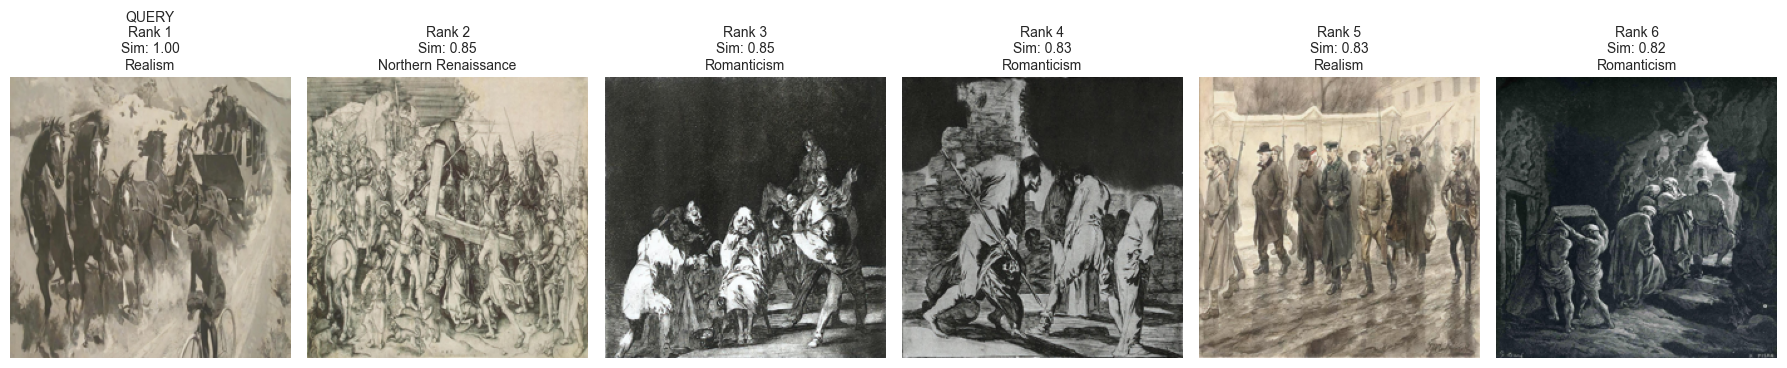

In [21]:
# --- MEJORA 5: Sistema de Retrieval por Similitud de Coseno ---
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def retrieve_similar_paintings(query_filename, embeddings, df, top_k=6):
    """
    Recupera y muestra las top_k imágenes más similares a la imagen de consulta.
    """
    if query_filename not in df['filename'].values:
        print(f"Error: La imagen {query_filename} no se encuentra en el dataframe.")
        return
    
    # Obtener el índice de la imagen de consulta en el dataframe
    query_idx = df[df['filename'] == query_filename].index[0]
    # Mapear al índice de la fila en la matriz de embeddings (0 a N_SAMPLES-1)
    list_idx = df.index.tolist()
    row_idx = list_idx.index(query_idx)
    
    query_embedding = embeddings[row_idx].reshape(1, -1)
    
    # Calcular similitudes de coseno
    similarities = cosine_similarity(query_embedding, embeddings).flatten()
    
    # Obtener las top_k más similares (incluyendo el propio query en primera posición)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    print(f"Obra de Consulta: {query_filename}")
    query_row = df.iloc[row_idx]
    print(f"  Género Real: {query_row['genre_principal']}")
    print(f"  Descripción: {query_row['description']}")
    print("-" * 50)
    
    fig, axes = plt.subplots(1, top_k, figsize=(18, 5))
    if top_k == 1:
        axes = [axes]
        
    for rank, idx_sim in enumerate(top_indices):
        row_sim = df.iloc[idx_sim]
        sim_score = similarities[idx_sim]
        
        # Cargar la imagen o crear marcador de posición
        img_path = Path(IMG_DIR) / row_sim['filename']
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((224, 224))
        except Exception:
            img = Image.new('RGB', (224, 224), color=(200, 200, 200))
            
        axes[rank].imshow(img)
        title = f"Rank {rank+1}\nSim: {sim_score:.2f}\n{row_sim['genre_principal']}"
        if rank == 0:
            title = "QUERY\n" + title
        axes[rank].set_title(title, fontsize=10)
        axes[rank].axis('off')
        
        print(f"Rank {rank+1} (Sim: {sim_score:.4f}): {row_sim['filename']} | Género: {row_sim['genre_principal']}")
    
    plt.tight_layout()
    plt.show()

# Demostración del sistema de recuperación
if len(sample_df) > 0:
    # Usar el primer elemento del sample_df
    query_img = sample_df.iloc[0]['filename']
    retrieve_similar_paintings(query_img, real_embeddings, sample_df, top_k=6)
